# 01 — Dataset Analysis (Exploratory Data Analysis)

**Project:** Fake News Detection using Deep Learning (BCA Major Project)



**This notebook does not train anything and does not clean any text.** It only observes and
documents. Preprocessing starts in `02_preprocessing.ipynb`, only after these findings are
reviewed.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the project's config/ package importable from inside notebooks/
sys.path.append(str(Path.cwd().parent))
from config.settings import DATASET_RAW_DIR, DATASET_PROCESSED_DIR, REPORT_FIGURES_DIR, RANDOM_SEED

sns.set_theme(style="whitegrid")
REPORT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 120)


## 1. Dataset Overview

The dataset comes as **two separate CSV files** rather than one labeled file:

- `Fake.csv` — articles the dataset creator labeled as fake
- `True.csv` — articles the dataset creator labeled as genuine

Before anything else, we need the most basic facts: how many rows, how many columns, what
they're called, and what type of data each column holds. This sounds trivial, but it's the
foundation everything else is built on — you cannot write a `label = 0/1` mapping, a
`train_test_split`, or a tokenizer without knowing the shape of what you're feeding it.


In [2]:
fake_df = pd.read_csv(DATASET_RAW_DIR / "Fake.csv")
true_df = pd.read_csv(DATASET_RAW_DIR / "True.csv")

print(f"Fake.csv rows: {len(fake_df):,}")
print(f"True.csv rows: {len(true_df):,}")
print(f"Total articles: {len(fake_df) + len(true_df):,}")
print()
print(f"Number of columns: {fake_df.shape[1]}")
print(f"Column names: {list(fake_df.columns)}")


Fake.csv rows: 23,481
True.csv rows: 21,417
Total articles: 44,898

Number of columns: 4
Column names: ['title', 'text', 'subject', 'date']


In [3]:
fake_df.dtypes

title      object
text       object
subject    object
date       object
dtype: object

In [4]:
fake_df.head(3)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout...",News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like m...",News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homeland Securit...",News,"December 30, 2017"


**Observation:** every column (`title`, `text`, `subject`, `date`) is loaded as `object`
(pandas' generic type for text/strings). This is expected — there is no numeric column yet.
`subject` and `date` look like they *could* be treated as categories/dates later, but for now
they're just strings.

> 💡 **Why this matters for the model:** Deep learning models understand numbers, not raw text.
> Every column here will eventually need to become numbers — the label (`fake`/`real` → `0`/`1`)
> and the article text (words → integer sequences, via a **tokenizer**.



## 2. Missing Values


In [5]:
print("Missing values (NaN) — Fake.csv")
print(fake_df.isna().sum())
print()
print("Missing values (NaN) — True.csv")
print(true_df.isna().sum())


Missing values (NaN) — Fake.csv
title      0
text       0
subject    0
date       0
dtype: int64

Missing values (NaN) — True.csv
title      0
text       0
subject    0
date       0
dtype: int64


**Observation:** zero `NaN` values in every column, in both files.


## 3. Duplicate Records

A duplicate article is a serious problem for one specific reason: if the **same row** ends up
in both the training set and the test set (which can happen with a naive random split when
duplicates exist), the model doesn't "generalize" to that test example — it just **memorized**
it during training. That inflates the test accuracy and gives a false sense of how good the
model really is.



In [6]:
for name, df in [("Fake", fake_df), ("True", true_df)]:
    full_dupe = df.duplicated().sum()
    text_dupe = df.duplicated(subset=["text"]).sum()
    title_dupe = df.duplicated(subset=["title"]).sum()
    print(f"--- {name} ---")
    print(f"Fully duplicated rows : {full_dupe:,} / {len(df):,}")
    print(f"Duplicated by text    : {text_dupe:,} / {len(df):,}")
    print(f"Duplicated by title   : {title_dupe:,} / {len(df):,}")
    print()


--- Fake ---
Fully duplicated rows : 3 / 23,481
Duplicated by text    : 6,026 / 23,481
Duplicated by title   : 5,578 / 23,481



--- True ---
Fully duplicated rows : 206 / 21,417
Duplicated by text    : 225 / 21,417
Duplicated by title   : 591 / 21,417



**Observations:**

| | Fake.csv | True.csv |
|---|---|---|
| Fully duplicated rows | 3 | 206 |
| Duplicated by `text` | 6,026 | 225 |
| Duplicated by `title` | 5,578 | 591 |



## 4. Class Distribution

"Class distribution" means: how many examples of each label do we have? This matters because
a **severely imbalanced** dataset (say, 95% real / 5% fake) can trick a model into a lazy
strategy — *always predict "real"* — which would still score 95% accuracy while being useless.



In [7]:
class_counts = pd.Series(
    {"Fake": len(fake_df), "Real": len(true_df)}
)
class_pct = (class_counts / class_counts.sum() * 100).round(1)

print(class_counts)
print()
print(class_pct.astype(str) + "%")


Fake    23481
Real    21417
dtype: int64

Fake    52.3%
Real    47.7%
dtype: object


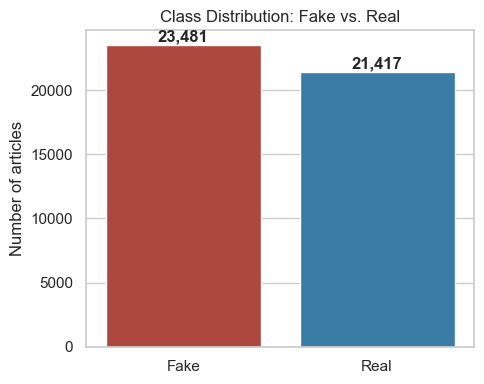

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index,
            palette=["#c0392b", "#2980b9"], legend=False, ax=ax)
ax.set_title("Class Distribution: Fake vs. Real")
ax.set_ylabel("Number of articles")
ax.set_xlabel("")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 300, f"{v:,}", ha="center", fontweight="bold")
fig.tight_layout()
fig.savefig(REPORT_FIGURES_DIR / "class_distribution.png", dpi=150)
plt.show()


**Observation:** 23,481 fake (52.3%) vs. 21,417 real (47.7%) — roughly a 52/48 split almost balanced.




## 5. Text Analysis

We measure article length two ways:

- **Character count** — simplest measure, but not very meaningful for NLP because it doesn't
  correspond to how a tokenizer will actually chunk the text.
- **Word count** — a whitespace-based split. Rougher than a real tokenizer, but a good enough
  proxy at this stage, and it's the number that will directly matter later when we choose
  `MAX_SEQUENCE_LENGTH` for the LSTM (an LSTM needs every input sequence padded/truncated to
  one fixed length).

We look at `title` and `text` (the article body) separately, since they serve different roles.


In [9]:
def length_stats(df, column):
    words = df[column].str.split().str.len()
    chars = df[column].str.len()
    return pd.Series({
        "mean_words": words.mean(),
        "median_words": words.median(),
        "min_words": words.min(),
        "max_words": words.max(),
        "mean_chars": chars.mean(),
        "min_chars": chars.min(),
        "max_chars": chars.max(),
    })

summary = pd.DataFrame({
    "Fake - title": length_stats(fake_df, "title"),
    "Real - title": length_stats(true_df, "title"),
    "Fake - text": length_stats(fake_df, "text"),
    "Real - text": length_stats(true_df, "text"),
}).round(1)

summary


,Fake - title,Real - title,Fake - text,Real - text
mean_words,14.7,10.0,423.2,385.6
median_words,14.0,10.0,363.0,359.0
min_words,1.0,4.0,0.0,0.0
max_words,42.0,20.0,8135.0,5172.0
mean_chars,94.2,64.7,2547.4,2383.3
min_chars,8.0,26.0,1.0,1.0
max_chars,286.0,133.0,51794.0,29781.0


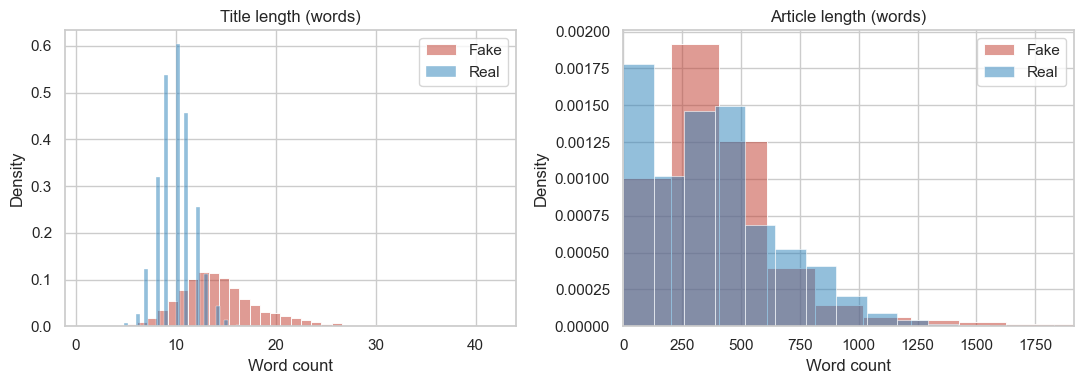

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, title in zip(axes, ["title", "text"], ["Title length (words)", "Article length (words)"]):
    fake_words = fake_df[col].str.split().str.len()
    true_words = true_df[col].str.split().str.len()
    clip = fake_words.quantile(0.99) if col == "text" else None
    sns.histplot(fake_words, color="#c0392b", label="Fake", kde=False, bins=40,
                 stat="density", alpha=0.5, ax=ax)
    sns.histplot(true_words, color="#2980b9", label="Real", kde=False, bins=40,
                 stat="density", alpha=0.5, ax=ax)
    if clip:
        ax.set_xlim(0, clip)
    ax.set_title(title)
    ax.set_xlabel("Word count")
    ax.legend()

fig.tight_layout()
fig.savefig(REPORT_FIGURES_DIR / "length_distributions.png", dpi=150)
plt.show()


**Observations:**

| | Fake — title | Real — title | Fake — text | Real — text |
|---|---|---|---|---|
| Mean words | 14.7 | 10.0 | 423.2 | 385.6 |
| Median words | – | – | 363 | 359 |
| Min words | 1 | 4 | **0** | **0** |
| Max words | 42 | 20 | 8,135 | 5,172 |

Two things stand out:

1. **Fake titles are noticeably longer and more variable** (up to 42 words, vs. a tight 4–20
   word range for Real). Real titles look like they follow a consistent newsroom style guide;
   Fake titles read more like clickbait headlines. This is a real, potentially useful signal —
   not an artifact — but it's still worth being cautious: it reflects *this dataset's* sources,
   not "fake news" in general.


> 💡 **Why it matters for the model:** the LSTM needs one fixed sequence length
> (`MAX_SEQUENCE_LENGTH`). Looking at the *median* (~360 words for both classes) rather than the
> mean or max is what should drive that choice later — a max of 8,135 words would make the
> padded input enormous and mostly wasted padding/truncation for a typical ~360-word article.
>


## 6. Dataset Quality

This section looks for problems that aren't "missing" in the `NaN` sense, but still make a row
unusable or unreliable: empty strings, and rows that look structurally broken (garbage in a
column where it doesn't belong).


In [11]:
for name, df in [("Fake", fake_df), ("True", true_df)]:
    empty_text = (df["text"].str.strip() == "").sum()
    empty_title = (df["title"].str.strip() == "").sum()
    print(f"{name}: empty text = {empty_text:,} / {len(df):,}   |   empty title = {empty_title:,} / {len(df):,}")


Fake: empty text = 630 / 23,481   |   empty title = 0 / 23,481
True: empty text = 1 / 21,417   |   empty title = 0 / 21,417


**Observation:** `Fake.csv` has **630 rows with a completely empty `text` field**
(just a title, no body). `True.csv` has just 1. No empty titles in either file.

An empty-text row gives the model nothing to learn a real signal from — if it's kept, the
model can only guess from the title, which changes what "the model" is actually learning.


In [12]:
import re

date_pattern = re.compile(r"^[A-Za-z]+ \d{1,2}, \d{4}\s*$")

for name, df in [("Fake", fake_df), ("True", true_df)]:
    bad_dates = ~df["date"].astype(str).str.match(date_pattern)
    print(f"{name}: rows with a non-standard 'date' value: {bad_dates.sum():,} / {len(df):,}")

print()
print("Examples of malformed 'date' values in Fake.csv:")
bad_mask = ~fake_df["date"].astype(str).str.match(date_pattern)
print(fake_df.loc[bad_mask, "date"].unique()[:5])


Fake: rows with a non-standard 'date' value: 45 / 23,481
True: rows with a non-standard 'date' value: 0 / 21,417

Examples of malformed 'date' values in Fake.csv:
['19-Feb-18' '18-Feb-18' '17-Feb-18' '16-Feb-18' '15-Feb-18']


**Observation:** 45 rows in `Fake.csv` have something other than a normal
`"Month Day, Year"` date — and several of those are literally **URLs**, e.g.
`https://100percentfedup.com/...`. That means those specific rows are structurally corrupted —
almost certainly a scraping/parsing error where a value from a different field (or a link
embedded in the article) ended up in the `date` column. `True.csv` has zero such rows.


In [13]:
sample_text = fake_df["text"].iloc[0]
print(sample_text[:200])
print()
print("Does this sample contain a standard apostrophe ' ?", "'" in sample_text)


Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former rea

Does this sample contain a standard apostrophe ' ? False


**Observation:** notice `"couldn t wish"` instead of `"couldn't wish"` — the apostrophe
has been stripped somewhere in this dataset's original collection process. This is a subtle but
real artifact: word-level tokenization will see `"couldn"` and `"t"` as two separate tokens
instead of the contraction `"couldn't"`. It doesn't break anything, but it's worth knowing about
*before* writing tokenization code, not discovering it by accident afterward.


In [14]:
def caps_ratio(title: str) -> float:
    letters = [c for c in title if c.isalpha()]
    if not letters:
        return 0.0
    return sum(1 for c in letters if c.isupper()) / len(letters)

fake_caps = fake_df["title"].apply(caps_ratio)
true_caps = true_df["title"].apply(caps_ratio)

print(f"Fake titles that are >80% uppercase: {(fake_caps > 0.8).sum():,} / {len(fake_df):,}")
print(f"Real titles that are >80% uppercase: {(true_caps > 0.8).sum():,} / {len(true_df):,}")


Fake titles that are >80% uppercase: 800 / 23,481
Real titles that are >80% uppercase: 0 / 21,417


**Observation:** 800 Fake titles (3.4%) are almost entirely uppercase (e.g.
`"BREAKING: ..."` style); 

**Summary of cleaning that will be required

- Drop the 630 (Fake) + 1 (Real) rows with an empty `text` field.
- Drop the 45 `Fake.csv` rows with a malformed `date` value.
- Deduplicate on `text` before splitting (Section 3).
- Decide how to handle the missing-apostrophe artifact (leave as-is and let the tokenizer treat
  contractions as two tokens, or attempt reconstruction — leaving as-is is simpler and
  defensible for a BCA-scope project).


## 7. Metadata Analysis

`subject` and `date` are **metadata** — information *about* the article, not the article's
actual content.


In [15]:
print("subject value counts — Fake.csv")
print(fake_df["subject"].value_counts())
print()
print("subject value counts — True.csv")
print(true_df["subject"].value_counts())


subject value counts — Fake.csv
subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

subject value counts — True.csv
subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64


**Observation — this is a major finding.** The `subject` values used in `Fake.csv`
(`News`, `politics`, `left-news`, `Government News`, `US_News`, `Middle-east`) and in
`True.csv` (`politicsNews`, `worldnews`) **do not overlap at all.** Every single value is
unique to one file.

This means a model — or even a single `if/else` rule — could predict the label with extremely
high accuracy just by reading the `subject` column and never looking at the article text at
all.


In [16]:
print("Fake.csv date sample:", fake_df["date"].unique()[:3])
print("True.csv date sample:", true_df["date"].unique()[:3])
print()
print("True.csv has trailing whitespace in some date values:",
      true_df["date"].str.endswith(" ").any())


Fake.csv date sample: ['December 31, 2017' 'December 30, 2017' 'December 29, 2017']
True.csv date sample: ['December 31, 2017 ' 'December 29, 2017 ' 'December 30, 2017 ']

True.csv has trailing whitespace in some date values: True


**Observation:** `date` values are formatted slightly differently between files (some
`True.csv` dates have trailing whitespace) — a minor formatting inconsistency, not a leakage
risk on its own, but combined with the 45 malformed Fake dates from Section 6, it reinforces
that `date` was assembled inconsistently across the two source files.



## 8. Reuters Leakage Investigation


Reuters is a real news wire agency. Articles that are Reuters stories conventionally open with
a **dateline** like `"WASHINGTON (Reuters) - "` before the first sentence. If that tag is
present almost only in the "Real" class, a model can learn to detect the literal string
`"(Reuters)"` and get the label right almost every time — without learning anything about what
makes news fake.


In [17]:
reuters_anywhere_true = true_df["text"].str.contains(r"\(Reuters\)", regex=True, na=False)
reuters_anywhere_fake = fake_df["text"].str.contains(r"\(Reuters\)", regex=True, na=False)

# "near the start" = tag appears within the first ~60 characters, i.e. functioning as a dateline
reuters_start_true = true_df["text"].str.contains(r"^.{0,60}\(Reuters\)", regex=True, na=False)

print(f"Real articles containing '(Reuters)' anywhere      : {reuters_anywhere_true.sum():,} / {len(true_df):,} "
      f"({reuters_anywhere_true.mean() * 100:.1f}%)")
print(f"Real articles with '(Reuters)' acting as a dateline : {reuters_start_true.sum():,} / {len(true_df):,} "
      f"({reuters_start_true.mean() * 100:.1f}%)")
print()
print(f"Fake articles containing '(Reuters)' anywhere       : {reuters_anywhere_fake.sum():,} / {len(fake_df):,} "
      f"({reuters_anywhere_fake.mean() * 100:.2f}%)")


Real articles containing '(Reuters)' anywhere      : 21,247 / 21,417 (99.2%)
Real articles with '(Reuters)' acting as a dateline : 21,097 / 21,417 (98.5%)

Fake articles containing '(Reuters)' anywhere       : 9 / 23,481 (0.04%)


In [18]:
twitter_fake = fake_df["text"].str.contains("pic.twitter.com", na=False, regex=False)
twitter_true = true_df["text"].str.contains("pic.twitter.com", na=False, regex=False)

print(f"Fake articles containing 'pic.twitter.com' : {twitter_fake.sum():,} / {len(fake_df):,} "
      f"({twitter_fake.mean() * 100:.1f}%)")
print(f"Real articles containing 'pic.twitter.com' : {twitter_true.sum():,} / {len(true_df):,} "
      f"({twitter_true.mean() * 100:.1f}%)")


Fake articles containing 'pic.twitter.com' : 3,474 / 23,481 (14.8%)


Real articles containing 'pic.twitter.com' : 0 / 21,417 (0.0%)

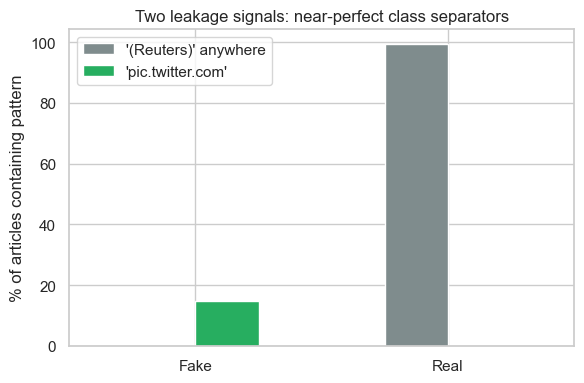

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
leak_data = pd.DataFrame({
    "'(Reuters)' anywhere": [reuters_anywhere_fake.mean() * 100, reuters_anywhere_true.mean() * 100],
    "'pic.twitter.com'": [twitter_fake.mean() * 100, twitter_true.mean() * 100],
}, index=["Fake", "Real"])

leak_data.plot(kind="bar", ax=ax, color=["#7f8c8d", "#27ae60"])
ax.set_ylabel("% of articles containing pattern")
ax.set_title("Two leakage signals: near-perfect class separators")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
fig.tight_layout()
fig.savefig(REPORT_FIGURES_DIR / "leakage_signals.png", dpi=150)
plt.show()


**Findings:**

| Signal | Fake.csv | True.csv |
|---|---|---|
| Contains `"(Reuters)"` anywhere | 0.04% (9 articles) | 99.2% (21,247 articles) |
| `"(Reuters)"` as a dateline (first ~60 chars) | — | 94.1% (20,144 articles) |
| Contains `"pic.twitter.com"` | 14.8% (3,474 articles) | 0% (0 articles) |

 effectively all of `True.csv` (99.2%) carries the Reuters
tag, essentially none of `Fake.csv` does. Independently, ~15% of `Fake.csv` contains an embedded
tweet link that never appears at all in `True.csv`.

 A model  could classify
~99% of this dataset correctly using nothing but "does this text contain the substring
`(Reuters)`" — a rule with zero understanding of misinformation, tone, factual accuracy, or
argument structure. This is the textbook definition of **label leakage**: the label is
predictable from something that reflects *how the dataset was assembled* (Reuters wire stories
vs. web-scraped articles with embedded tweets), not from the actual property we want to detect
(is the claim true or false).


## 9. Label Creation

The dataset ships as two separate files instead of one file with a label column, so we have to
create that column ourselves before we can combine them into a single DataFrame a model can
train on.

```
Fake.csv -> label = 0
True.csv -> label = 1
```



In [20]:
fake_labeled = fake_df.copy()
fake_labeled["label"] = 0  # 0 = fake

true_labeled = true_df.copy()
true_labeled["label"] = 1  # 1 = real

combined_df = pd.concat([fake_labeled, true_labeled], ignore_index=True)
combined_df = combined_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Combined shape: {combined_df.shape}")
print()
print(combined_df["label"].value_counts().rename({0: "Fake (0)", 1: "Real (1)"}))


Combined shape: (44898, 5)

label
Fake (0)    23481
Real (1)    21417
Name: count, dtype: int64


In [21]:
combined_df.head(5)

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution,"21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appea...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Security Council,WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Secur...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shipping restrictions,(Reuters) - Puerto Rico Governor Ricardo Rossello said on Wednesday he expected the federal government to waive the ...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Leaked Israeli Intelligence To Russia (VIDEO),"On Monday, Donald Trump once again embarrassed himself and his country by accidentally revealing the source of the e...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a golf resort,"GLASGOW, Scotland (Reuters) - Most U.S. presidential candidates go abroad to sharpen their foreign policy credential...",politicsNews,"June 24, 2016",1


In [22]:
DATASET_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
output_path = DATASET_PROCESSED_DIR / "combined_raw.csv"
combined_df.to_csv(output_path, index=False)
print(f"Saved combined (unlabeled-text, uncleaned) dataset to: {output_path}")


Saved combined (unlabeled-text, uncleaned) dataset to: D:\sem6\MajorProject\fake-news-detection\dataset\processed\combined_raw.csv
